In [3]:
pip install opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import cv2
import matplotlib.pyplot as plt

In [5]:
image_path = "gato.jpeg"
image = cv2.imread(image_path)

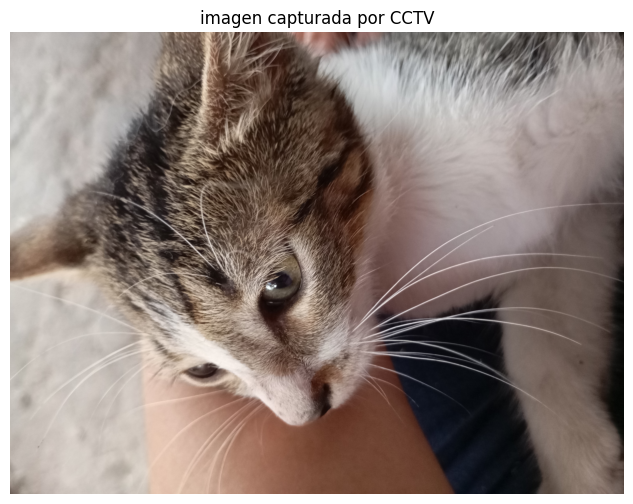

In [4]:
if image is None:
    print("hay un error, no se cargó la imagen")
else:
    image_rbg = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) 

    #mostrando la imagen usando matplotlib
    plt.figure(figsize=(8,6))
    plt.imshow(image_rbg)
    plt.title("imagen capturada por CCTV")
    plt.axis("off")
    plt.show()   


2) Técnicas de Mejora, Corrección y Anotación de Imágenes
Objetivo:
Optimizar la calidad visual de las imágenes capturadas por cámaras de CCTV y aplicar anotaciones que faciliten la identificación de eventos críticos.

2.1) Ajuste de brillo y contraste

In [6]:
# Cargar la imagen de CCTV
image_path = "gato.jpeg"
image = cv2.imread(image_path)
if image is None:
    print("Error: No se pudo cargar la imagen.")
    exit()

# Ajuste de brillo y contraste: new_image = image * alpha + beta
alpha = 1.2  # Factor de contraste (mayor a 1 aumenta contraste)
beta = 50    # Valor de brillo (positivo aumenta el brillo)
adjusted = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

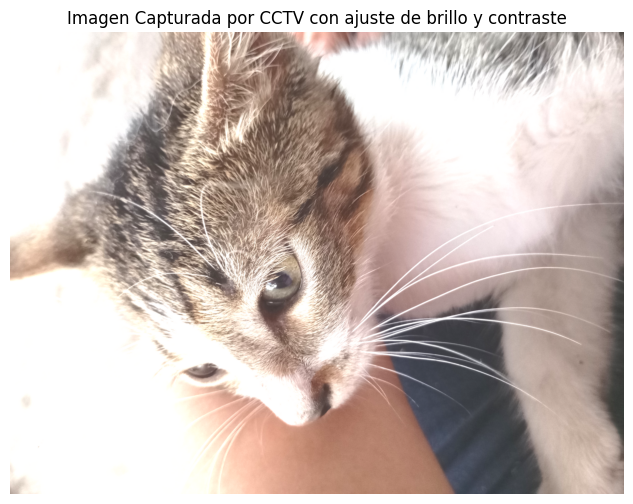

In [7]:
# Convertir la imagen de BGR (formato OpenCV) a RGB (formato matplotlib)
adjusted = cv2.cvtColor(adjusted, cv2.COLOR_BGR2RGB)

# Mostrar la imagen usando matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(adjusted)
plt.title("Imagen Capturada por CCTV con ajuste de brillo y contraste")
plt.axis("off")
plt.show()


In [8]:
# Guardar imagen para comparar
output_file = "./gato_con_brillo.jpg"
cv2.imwrite(output_file, adjusted)

True

2.2) Corrección de color y normalización

In [9]:
import numpy as np

El espacio de color HSV (Hue, Saturation, Value) representa los colores según su matiz, saturación y valor.
Convertir una imagen a HSV facilita la manipulación de la saturación, permitiendo ajustar la intensidad o pureza de los colores sin afectar el brillo o el tono.

In [10]:
# Convertir la imagen ajustada a espacio HSV para modificar la saturación
hsv = cv2.cvtColor(adjusted, cv2.COLOR_BGR2HSV)

In [11]:
h, s, v = cv2.split(hsv)

# Aumentar la saturación
saturacion = 5

s = cv2.multiply(s, saturacion)  
s = np.clip(s, 0, 255).astype(np.uint8)
hsv_adjusted = cv2.merge([h, s, v])
color_corrected = cv2.cvtColor(hsv_adjusted, cv2.COLOR_HSV2BGR)

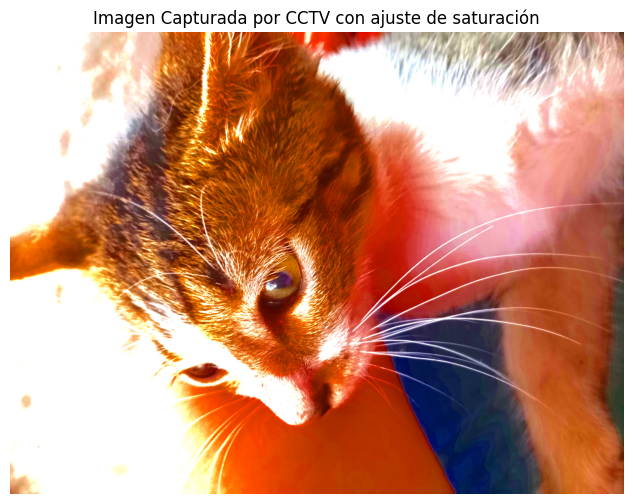

In [12]:
# Mostrar la imagen usando matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(color_corrected)
plt.title("Imagen Capturada por CCTV con ajuste de saturación")
plt.axis("off")
plt.show()

In [13]:
# Convertir la imagen de BGR (formato OpenCV) a RGB (formato matplotlib)
color_corrected = cv2.cvtColor(color_corrected, cv2.COLOR_BGR2RGB)

# Guardar imagen para comparar
output_file = "./gato_con_saturacion.jpg"
cv2.imwrite(output_file, color_corrected)

True

2.3) Aplicación de anotaciones

In [14]:
# Hacer una copia de una imagen ya cargada
annotated = image.copy()

# Dibujar una línea: desde (150,250) hasta (350,250) en azul BGR: (255, 0, 0) con grosor de línea 3 píxeles
cv2.line(annotated, (150, 500), (1500, 500), (255, 0, 0), 30)
# Dibujar un rectángulo: esquina superior izquierda (150, 300), inferior derecha (350,600) en verde BGR: (0, 255, 0)
cv2.rectangle(annotated, (200, 600), (1000, 1500), (0, 255, 0), 20)
# Escribir texto: 'Persona' en rojo BGR: (0, 0, 255), ubicado en (200,290)
cv2.putText(annotated, 'Gatito', (200, 400), cv2.FONT_HERSHEY_SIMPLEX, 20, (0, 0, 255), 30)

array([[[182, 186, 191],
        [181, 185, 190],
        [179, 183, 188],
        ...,
        [ 17,  21,  26],
        [ 18,  22,  27],
        [ 18,  22,  27]],

       [[179, 183, 188],
        [179, 183, 188],
        [178, 182, 187],
        ...,
        [ 17,  21,  26],
        [ 17,  21,  26],
        [ 17,  21,  26]],

       [[177, 181, 186],
        [177, 181, 186],
        [177, 181, 186],
        ...,
        [ 17,  21,  26],
        [ 17,  21,  26],
        [ 17,  21,  26]],

       ...,

       [[ 78,  86,  99],
        [ 79,  87, 100],
        [ 81,  89, 102],
        ...,
        [ 70,  78,  91],
        [ 69,  77,  90],
        [ 68,  76,  89]],

       [[ 77,  85,  98],
        [ 79,  87, 100],
        [ 81,  89, 102],
        ...,
        [ 72,  80,  93],
        [ 70,  78,  91],
        [ 69,  77,  90]],

       [[ 77,  85,  98],
        [ 79,  87, 100],
        [ 81,  89, 102],
        ...,
        [ 72,  80,  93],
        [ 71,  79,  92],
        [ 69,  77,  90]]

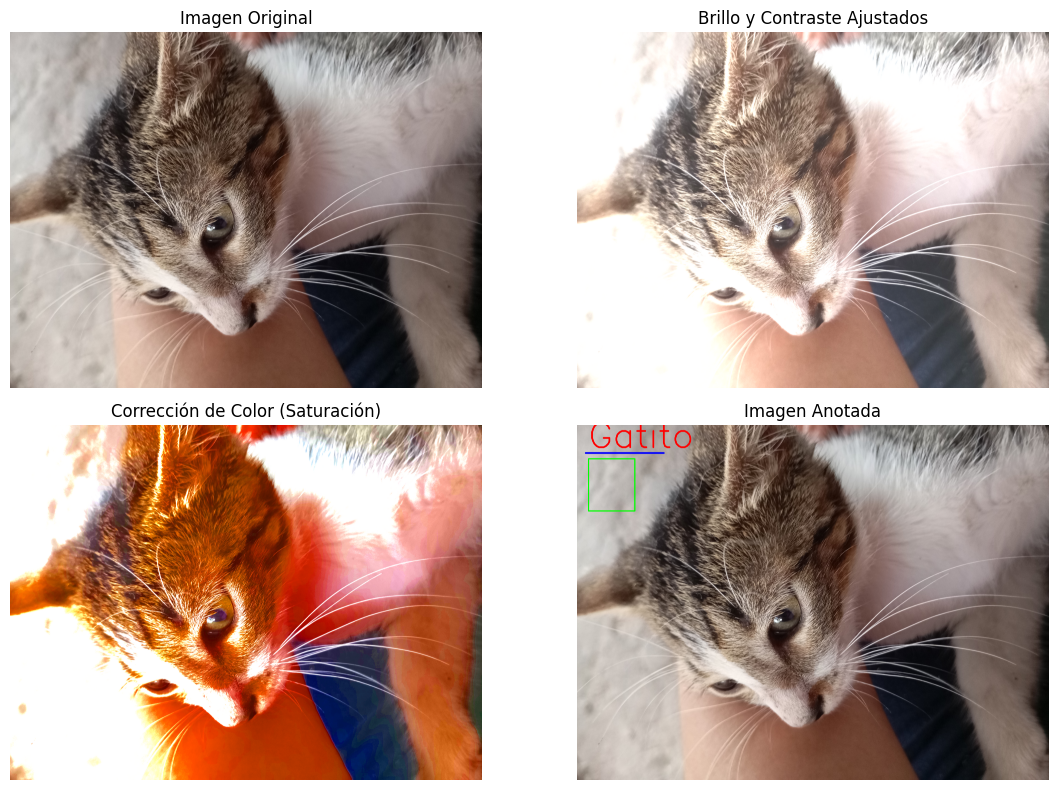

In [15]:
# Convertir de BGR a RGB para visualizar con matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
adjusted_rgb = adjusted
color_corrected_rgb = cv2.cvtColor(color_corrected, cv2.COLOR_BGR2RGB)
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(image_rgb)
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(adjusted_rgb)
plt.title("Brillo y Contraste Ajustados")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(color_corrected_rgb)
plt.title("Corrección de Color (Saturación)")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(annotated_rgb)
plt.title("Imagen Anotada")
plt.axis("off")

plt.tight_layout()
plt.show()